In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("Crop_recommendation.csv")
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [ ]:
df.shape

(2200, 8)

In [ ]:
df.isna()

,N,P,K,temperature,humidity,ph,rainfall,label
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
2195,False,False,False,False,False,False,False,False
2196,False,False,False,False,False,False,False,False
2197,False,False,False,False,False,False,False,False
2198,False,False,False,False,False,False,False,False


In [ ]:
df.isna().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [ ]:
df.dtypes

,0
N,int64
P,int64
K,int64
temperature,float64
humidity,float64
ph,float64
rainfall,float64
label,object


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
N,137
P,117
K,73
temperature,2200
humidity,2200
ph,2200
rainfall,2200
label,22


In [ ]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
label_counts = df['label'].value_counts()
label_counts


,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


<function matplotlib.pyplot.show(close=None, block=None)>

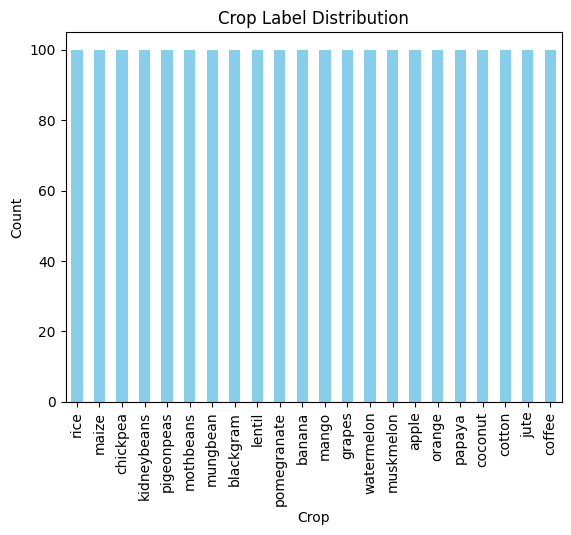

In [ ]:
plt.Figure(figsize=(10,5))
label_counts.plot(kind='bar', color = 'skyblue')
plt.title("Crop Label Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.show


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [ ]:
X = df[['N','P','K','temperature','humidity','ph','rainfall']]
y = df['label']

In [ ]:
X_train,X_test,y_train,y_test =  train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


In [ ]:
X_train

,N,P,K,temperature,humidity,ph,rainfall
1607,0,18,14,29.771494,92.007200,7.207991,114.416179
1212,9,122,201,29.587484,80.919344,5.570291,68.064173
362,11,71,24,21.140114,22.718235,5.606620,141.605672
566,38,38,18,26.310518,61.187491,6.294130,35.734038
1671,18,12,8,12.590940,91.816688,6.206053,119.391672
...,...,...,...,...,...,...,...
808,13,64,20,19.134577,62.575269,6.590571,36.469470
422,16,55,19,19.543141,47.191883,6.413544,192.437219
2052,82,48,36,25.793520,81.769040,6.352077,193.241838
2083,90,50,44,26.916437,73.486560,6.253409,171.471638


In [ ]:
X_test

,N,P,K,temperature,humidity,ph,rainfall
1609,13,23,6,23.961476,90.264080,7.365338,102.695870
1072,98,79,50,25.341198,84.473213,6.435917,91.064934
1912,140,38,15,24.147295,75.882986,6.021440,69.915635
100,71,54,16,22.613600,63.690706,5.749914,87.759539
1645,40,22,6,24.536101,91.909972,6.488221,115.978799
...,...,...,...,...,...,...,...
140,99,56,17,24.108592,73.131123,6.234330,71.075622
1587,1,135,203,22.778565,92.701240,5.624203,113.775922
2015,70,38,35,24.397362,79.268617,7.014064,164.269701
1254,21,134,202,10.723025,80.021306,6.425420,65.298211


In [ ]:
y_train

,label
1607,orange
1212,grapes
362,kidneybeans
566,mothbeans
1671,orange
...,...
808,lentil
422,pigeonpeas
2052,jute
2083,jute


In [ ]:
y_test

,label
1609,orange
1072,banana
1912,cotton
100,maize
1645,orange
...,...
140,maize
1587,apple
2015,jute
1254,grapes


In [ ]:
scaler = StandardScaler()
X_train_Scaled = scaler.fit_transform(X_train)
X_test_Scaled = scaler.fit_transform(X_test)


In [ ]:
X_train_Scaled_df = pd.DataFrame(X_train_Scaled,columns=X_train.columns)


In [ ]:
models = {
    "Random Forst" : RandomForestClassifier(n_estimators=200,random_state=42),
    "Decision Tree" : DecisionTreeClassifier(random_state=42),
    "KNN" : KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression " : LogisticRegression(max_iter=200,random_state=42),
    "SVM(RBF Kernel)" : SVC(kernel='rbf',random_state=42),
}

In [ ]:
results = []
for name, model in models.items():
    if name in ["KNN","Logistic Regression ","SVM(RBF Kernel)"]:
        model.fit(X_train_Scaled, y_train)
        preds = model.predict(X_test_Scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    accuracy = accuracy_score(y_test, preds)
    results.append((name, accuracy))

In [ ]:
results

[('Random Forst', 0.9954545454545455),
 ('Decision Tree', 0.9795454545454545),
 ('KNN', 0.9795454545454545),
 ('Logistic Regression ', 0.9727272727272728),
 ('SVM(RBF Kernel)', 0.9863636363636363)]

In [ ]:
results_df = pd.DataFrame(results,columns=['Model','Accuracy'])
results_df

,Model,Accuracy
0,Random Forst,0.995455
1,Decision Tree,0.979545
2,KNN,0.979545
3,Logistic Regression,0.972727
4,SVM(RBF Kernel),0.986364


In [ ]:
results_df =  results_df.sort_values(by='Accuracy',ascending=False)
results_df

,Model,Accuracy
0,Random Forst,0.995455
4,SVM(RBF Kernel),0.986364
1,Decision Tree,0.979545
2,KNN,0.979545
3,Logistic Regression,0.972727


In [ ]:
import pickle as plk

In [ ]:
best_model = RandomForestClassifier(n_estimators=200,random_state=42)
best_model.fit(X_train,y_train)
preds = best_model.predict(X_test)
accuracy = accuracy_score(y_test,preds)
print (f"Best Model Accuracy : {accuracy}")

Best Model Accuracy : 0.9954545454545455


In [ ]:
bondle = {
    "model" : best_model,
    "feature_cols" : ['N','P','K','temperature','humidity','ph','rainfall'],
    "Classes" : best_model.classes_
}


In [ ]:
with open("Crop_Recommendation_RF.pkl","wb") as f:
  plk.dump(bondle,f)
  print("Model Saved as Crop_Recommendation_RF.pkl")

Model Saved as Crop_Recommendation_RF.pkl


In [ ]:
with open("Crop_Recommendation_RF.pkl","rb") as f:
    b = plk.load(f)


In [ ]:
print (type(b["model"]),b["feature_cols"],b["Classes"][:3])

<class 'sklearn.ensemble._forest.RandomForestClassifier'> ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'] ['apple' 'banana' 'blackgram']


In [ ]:
sample = {'N':90,'P':40,'K':40,'temperature':20,'humidity':80,'ph':7,'rainfall':200}
X = [[sample[c] for c in b["feature_cols"]]]
X

[[90, 40, 40, 20, 80, 7, 200]]

In [ ]:
print("Pred:" , b["model"].predict(X)[0])

Pred: rice


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
